# NEXTBUY

Analyse de millions de commandes clients pour extraire des **insights business** et construire des **modèles prédictifs**.

Données : commandes de milliers de clients d'une enseigne de grande distribution. Chaque client peut passer plusieurs commandes, chaque commande contient un ou plusieurs produits, regroupés en rayons (`aisle`) et départements (`department`).

## Questions Business

Les 10 insights que nous cherchons à extraire :

| # | Question |
|---|----------|
| 1 | Quand et comment les clients commandent-ils ? |
| 2 | Quel est le délai typique entre deux commandes ? |
| 3 | Quels sont les produits bestsellers ? |
| 4 | Quelle est la part des produits bio dans les légumes ? |
| 5 | Quel produit est mis en premier dans le panier ? |
| 6 | Quels produits ont la plus forte probabilité de réachat ? |
| 7 | Y a-t-il un lien entre le délai de réachat et la probabilité de réachat ? |
| 8 | Quels sont les profils types de clients ? |
| 9 | Quel jour les clients fidèles/accros viennent-ils le plus et quels produits consomment-ils ? |
| 10 | Quels produits mettre en avant le samedi ? |

---
## Imports

- **pandas** : manipulation de données tabulaires
- **numpy** : calculs numériques
- **matplotlib / seaborn** : visualisations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

---
## Chargement des données

5 fichiers CSV :
- `orders.csv` — une ligne par commande (user, jour, heure, délai)
- `order_products.csv` — une ligne par produit dans une commande
- `products.csv`, `aisles.csv`, `departments.csv` — référentiels produits

In [2]:
DATA_DIR = 'datasets/'

orders         = pd.read_csv(DATA_DIR + 'orders.csv')
products       = pd.read_csv(DATA_DIR + 'products.csv')
aisles         = pd.read_csv(DATA_DIR + 'aisles.csv')
departments    = pd.read_csv(DATA_DIR + 'departments.csv')
order_products = pd.read_csv(DATA_DIR + 'order_products.csv')

for name, t in {'orders': orders, 'products': products, 'aisles': aisles, 'departments': departments, 'order_products': order_products}.items():
    print(f'{name:18s} {str(t.shape):>15s}')

orders                (1444444, 6)
products                (49688, 4)
aisles                    (134, 2)
departments                (21, 2)
order_products       (13692886, 4)


---
## Fusion des données

On fusionne toutes les tables en un seul DataFrame `df` pour pouvoir croiser toutes les dimensions facilement.

In [3]:
df = order_products.merge(orders, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(aisles, on='aisle_id')
df = df.merge(departments, on='department_id')

print(f'DataFrame final : {df.shape}')
df.head()

DataFrame final : (13692437, 14)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,Natural Sweetener,17,13,baking ingredients,pantry


---
## Qualité des données

Avant d'analyser, on vérifie les valeurs manquantes dans chaque table.

In [4]:
for name, t in {'orders': orders, 'order_products': order_products, 'products': products, 'aisles': aisles, 'departments': departments}.items():
    missing = t.isna().sum()
    missing = missing[missing > 0]
    print(f'\n{name.upper()} ({t.shape[0]:,} x {t.shape[1]})')
    if not missing.empty:
        for col in missing.index:
            print(f'  {col}: {missing[col]:,} manquantes ({missing[col]/len(t)*100:.2f}%)')
    else:
        print('  Aucune valeur manquante')


ORDERS (1,444,444 x 6)
  user_id: 31 manquantes (0.00%)
  order_number: 23 manquantes (0.00%)
  order_dow: 22 manquantes (0.00%)
  order_hour_of_day: 23 manquantes (0.00%)
  days_since_prior_order: 86,909 manquantes (6.02%)

ORDER_PRODUCTS (13,692,886 x 4)
  product_id: 449 manquantes (0.00%)
  add_to_cart_order: 446 manquantes (0.00%)
  reordered: 449 manquantes (0.00%)

PRODUCTS (49,688 x 4)
  Aucune valeur manquante

AISLES (134 x 2)
  Aucune valeur manquante

DEPARTMENTS (21 x 2)
  Aucune valeur manquante


> **Constat** : Données très propres. Seul `days_since_prior_order` a ~6% de valeurs manquantes (normal : pas de commande précédente pour la 1ère commande).

---
## Q1/Q2 — Quand et comment les clients commandent-ils ?

Distribution temporelle des commandes : par heure, jour de la semaine, et délai entre deux commandes.

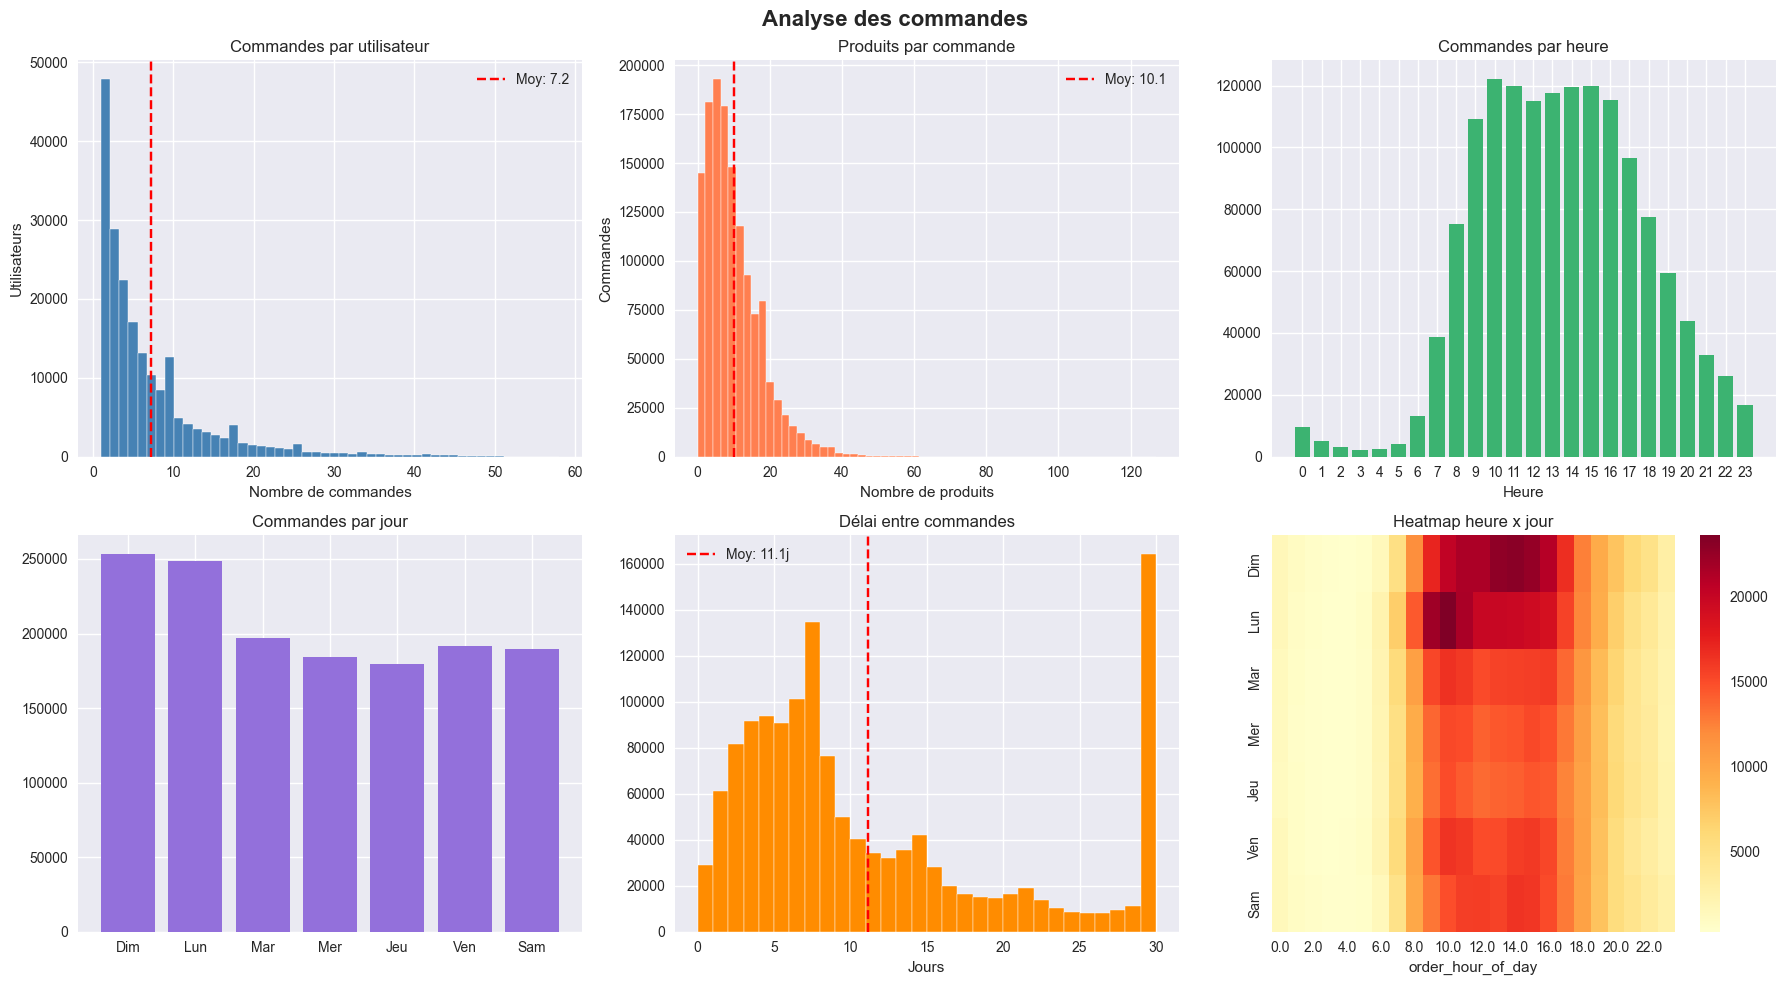

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Analyse des commandes", fontsize=16, fontweight='bold')

orders_per_user = orders.groupby('user_id')['order_id'].count()
axes[0, 0].hist(orders_per_user, bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Commandes par utilisateur")
axes[0, 0].set_xlabel("Nombre de commandes")
axes[0, 0].set_ylabel("Utilisateurs")
axes[0, 0].axvline(orders_per_user.mean(), color='red', linestyle='--', label=f"Moy: {orders_per_user.mean():.1f}")
axes[0, 0].legend()

products_per_order = order_products.groupby('order_id')['product_id'].count()
axes[0, 1].hist(products_per_order, bins=60, color='coral', edgecolor='white')
axes[0, 1].set_title("Produits par commande")
axes[0, 1].set_xlabel("Nombre de produits")
axes[0, 1].set_ylabel("Commandes")
axes[0, 1].axvline(products_per_order.mean(), color='red', linestyle='--', label=f"Moy: {products_per_order.mean():.1f}")
axes[0, 1].legend()

hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
axes[0, 2].bar(hour_counts.index, hour_counts.values, color='mediumseagreen')
axes[0, 2].set_title("Commandes par heure")
axes[0, 2].set_xlabel("Heure")
axes[0, 2].set_xticks(range(0, 24))

dow_labels = ['Dim', 'Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam']
dow_counts = orders['order_dow'].value_counts().sort_index()
axes[1, 0].bar(dow_labels, dow_counts.values, color='mediumpurple')
axes[1, 0].set_title("Commandes par jour")

dspo = orders['days_since_prior_order'].dropna()
axes[1, 1].hist(dspo, bins=30, color='darkorange', edgecolor='white')
axes[1, 1].set_title("Délai entre commandes")
axes[1, 1].set_xlabel("Jours")
axes[1, 1].axvline(dspo.mean(), color='red', linestyle='--', label=f"Moy: {dspo.mean():.1f}j")
axes[1, 1].legend()

pivot = orders.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)
pivot.index = dow_labels
sns.heatmap(pivot, ax=axes[1, 2], cmap='YlOrRd')
axes[1, 2].set_title("Heatmap heure x jour")

plt.tight_layout()
plt.show()

> **Réponse Q1/Q2** : Les clients commandent surtout le **dimanche et lundi**, entre **10h et 16h**. Le délai moyen entre deux commandes est d'environ **11 jours**, avec des pics nets à **7 jours** (hebdomadaire) et **30 jours** (mensuel).

---
## Q3 — Quels sont les produits bestsellers ?

On compte le nombre de fois que chaque produit, rayon et département apparaît dans les commandes.

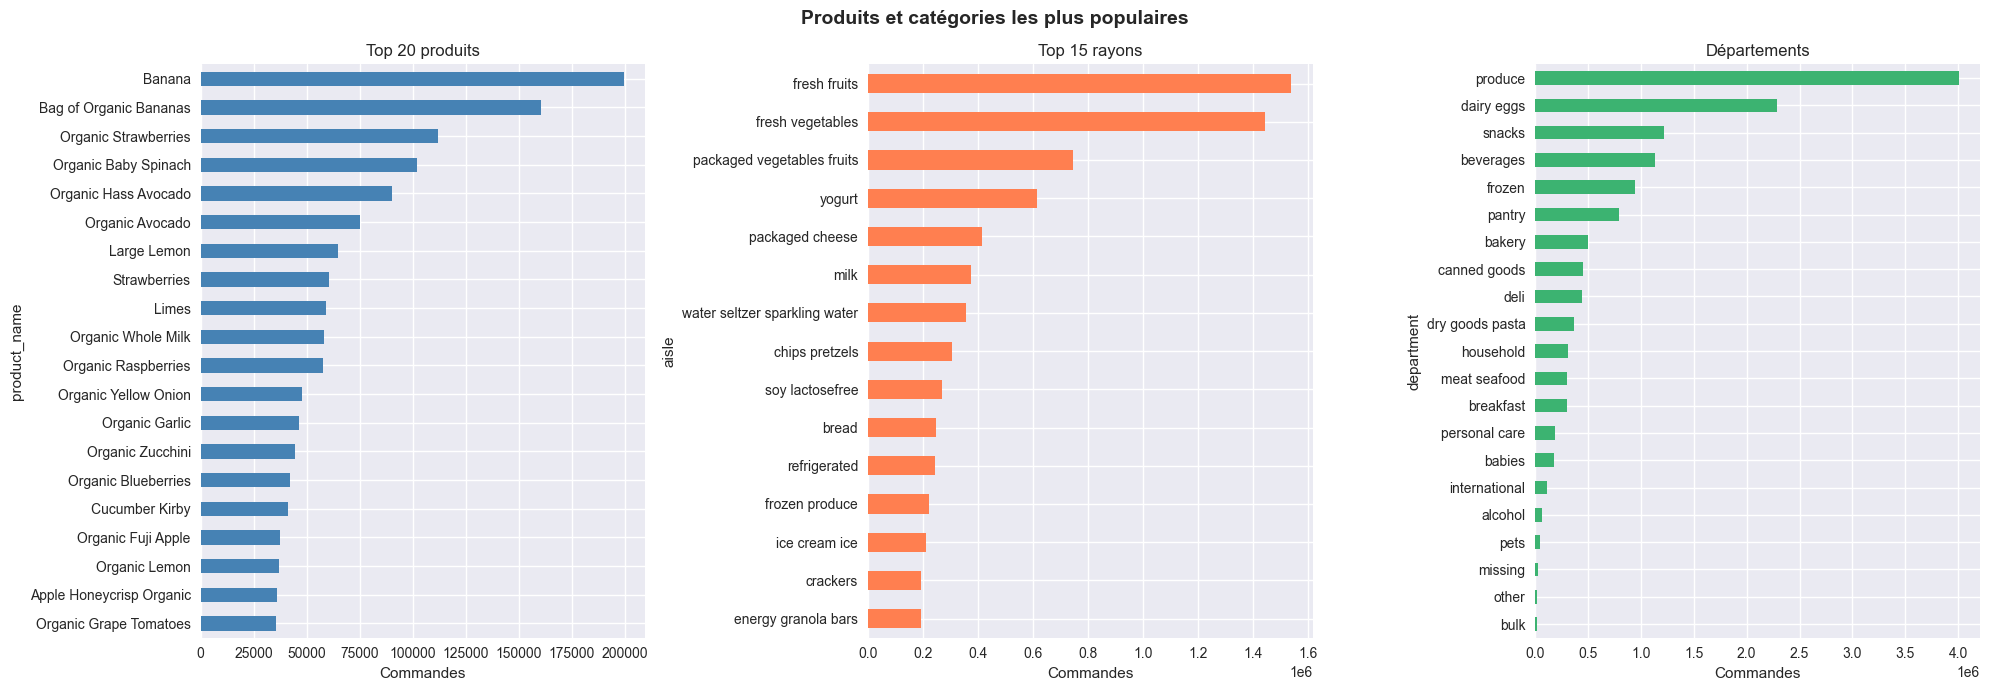

In [6]:
top_products = df['product_name'].value_counts().head(20)
top_aisles = df['aisle'].value_counts().head(15)
top_depts = df['department'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Produits et catégories les plus populaires", fontsize=14, fontweight='bold')

top_products[::-1].plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title("Top 20 produits")
axes[0].set_xlabel("Commandes")

top_aisles[::-1].plot.barh(ax=axes[1], color='coral')
axes[1].set_title("Top 15 rayons")
axes[1].set_xlabel("Commandes")

top_depts[::-1].plot.barh(ax=axes[2], color='mediumseagreen')
axes[2].set_title("Départements")
axes[2].set_xlabel("Commandes")

plt.tight_layout()
plt.show()

> **Réponse Q3** : Les **bananes** sont de loin le produit le plus commandé. Le département **produce** (fruits & légumes) domine largement. La longue traîne est marquée : quelques produits concentrent l'essentiel des ventes.

---
## Q4 — Quelle est la part des produits bio dans les légumes ?

On filtre les rayons contenant des légumes, puis on détecte les produits bio via le mot-clé `"Organic"` dans le nom.

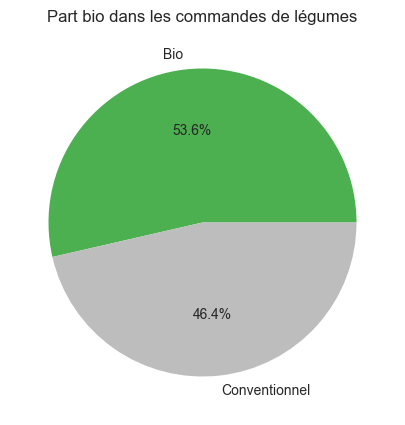

In [7]:
veg = df[df['aisle'].str.contains('vegetable|salad|greens', case=False)].copy()
veg['bio'] = veg['product_name'].str.contains('Organic', case=False)
bio_rate = veg['bio'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie([bio_rate, 1 - bio_rate], labels=['Bio', 'Conventionnel'], 
       colors=['#4caf50', '#bdbdbd'], autopct='%1.1f%%')
ax.set_title("Part bio dans les commandes de légumes")
plt.show()

> **Réponse Q4** : Une part significative des commandes de légumes concerne des produits bio, signe d'une forte demande pour le bio dans cette catégorie.

---
## Q5 — Quel produit est mis en premier dans le panier ?

`add_to_cart_order == 1` identifie le premier produit ajouté. C'est souvent un réflexe d'achat.

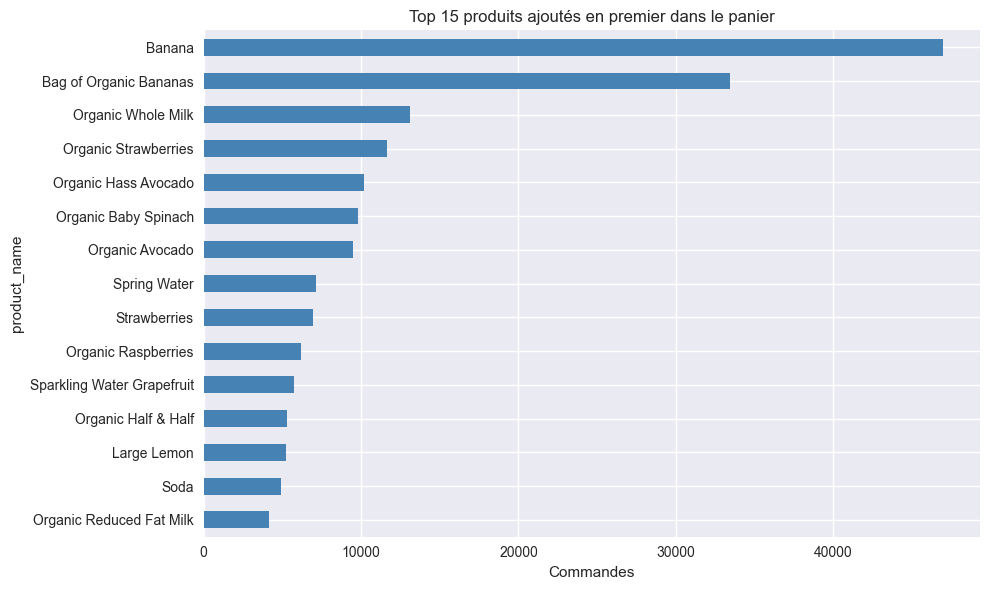

In [8]:
first = df[df['add_to_cart_order'] == 1]['product_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
first[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title("Top 15 produits ajoutés en premier dans le panier")
ax.set_xlabel("Commandes")
plt.tight_layout()
plt.show()

> **Réponse Q5** : Les produits frais (bananes, fruits, lait) sont systématiquement ajoutés en premier — des achats réflexes à mettre en avant en entrée de magasin.

---
## Q6 — Quels produits ont la plus forte probabilité de réachat ?

`reordered = 1` indique qu'un produit a déjà été commandé par ce client. On compare le taux de réachat par département et par position dans le panier.

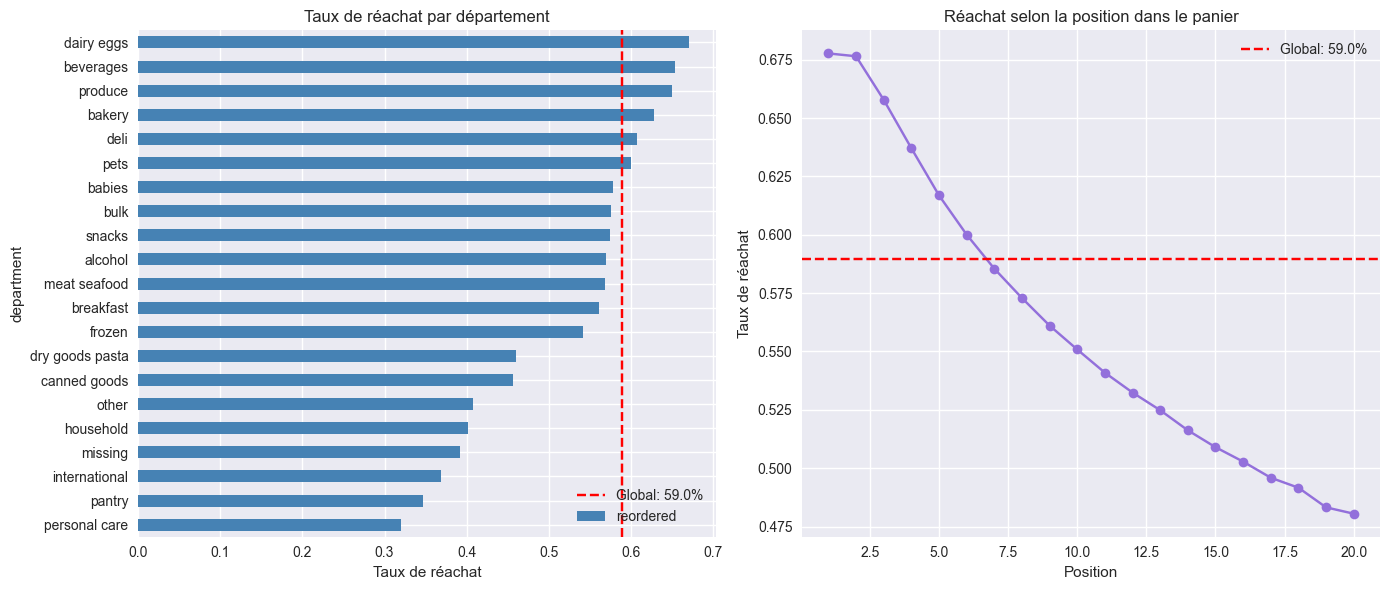

In [9]:
reorder_global = df['reordered'].mean()
reorder_dept = df.groupby('department')['reordered'].mean().sort_values(ascending=False)
reorder_cart = df[df['add_to_cart_order'] <= 20].groupby('add_to_cart_order')['reordered'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

reorder_dept[::-1].plot.barh(ax=axes[0], color='steelblue')
axes[0].axvline(reorder_global, color='red', linestyle='--', label=f'Global: {reorder_global:.1%}')
axes[0].set_title("Taux de réachat par département")
axes[0].set_xlabel("Taux de réachat")
axes[0].legend()

axes[1].plot(reorder_cart.index, reorder_cart.values, marker='o', color='mediumpurple')
axes[1].axhline(reorder_global, color='red', linestyle='--', label=f'Global: {reorder_global:.1%}')
axes[1].set_title("Réachat selon la position dans le panier")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Taux de réachat")
axes[1].legend()

plt.tight_layout()
plt.show()

> **Réponse Q6** : Taux de réachat global ~**59%**. Les produits ajoutés **en premier** dans le panier sont réachetés à ~80%. Les départements `dairy eggs` et `produce` ont les taux les plus élevés.

---
## Q7 — Lien entre délai de réachat et probabilité de réachat ?

On découpe `days_since_prior_order` en tranches et on regarde si un client qui commande rapidement rachète davantage les mêmes produits.

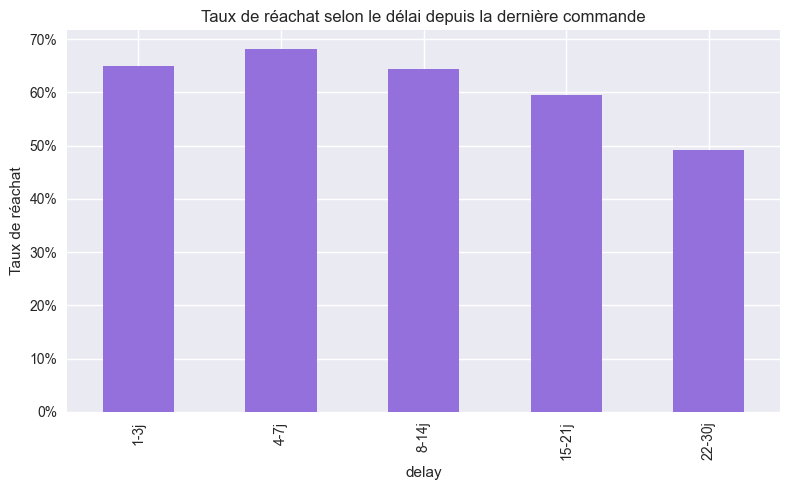

In [10]:
tmp = df.dropna(subset=['days_since_prior_order']).copy()
tmp['delay'] = pd.cut(tmp['days_since_prior_order'],
                      bins=[0, 3, 7, 14, 21, 30],
                      labels=['1-3j', '4-7j', '8-14j', '15-21j', '22-30j'])

reorder_delay = tmp.groupby('delay', observed=True)['reordered'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
reorder_delay.plot.bar(ax=ax, color='mediumpurple')
ax.set_title("Taux de réachat selon le délai depuis la dernière commande")
ax.set_ylabel("Taux de réachat")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

> **Réponse Q7** : Lien clair. Plus le **délai est court**, plus le client **rachète les mêmes produits**. Les commandes rapprochées (1-3j) sont des réapprovisionnements ciblés.

---
## Q8 — Quels sont les profils types de clients ?

On construit un profil par utilisateur :
- **Nombre de commandes** → fréquence
- **Taille moyenne du panier** → volume
- **Délai moyen entre commandes** → régularité

Puis on segmente en 5 groupes.

In [11]:
user_stats = orders.groupby('user_id').agg(
    nb_commandes=('order_id', 'count'),
    delai_moyen=('days_since_prior_order', 'mean')
).reset_index()

basket = df.groupby('user_id')['product_id'].count().reset_index(name='nb_produits')
user_stats = user_stats.merge(basket, on='user_id')
user_stats['panier_moy'] = user_stats['nb_produits'] / user_stats['nb_commandes']

user_stats['segment'] = pd.cut(
    user_stats['nb_commandes'],
    bins=[0, 5, 15, 30, 50, user_stats['nb_commandes'].max()],
    labels=['Occasionnel\n(1-5)', 'Régulier\n(6-15)', 'Actif\n(16-30)', 'Fidèle\n(31-50)', 'Accro\n(50+)']
)

Répartition des clients par segment et comparaison de leurs comportements :

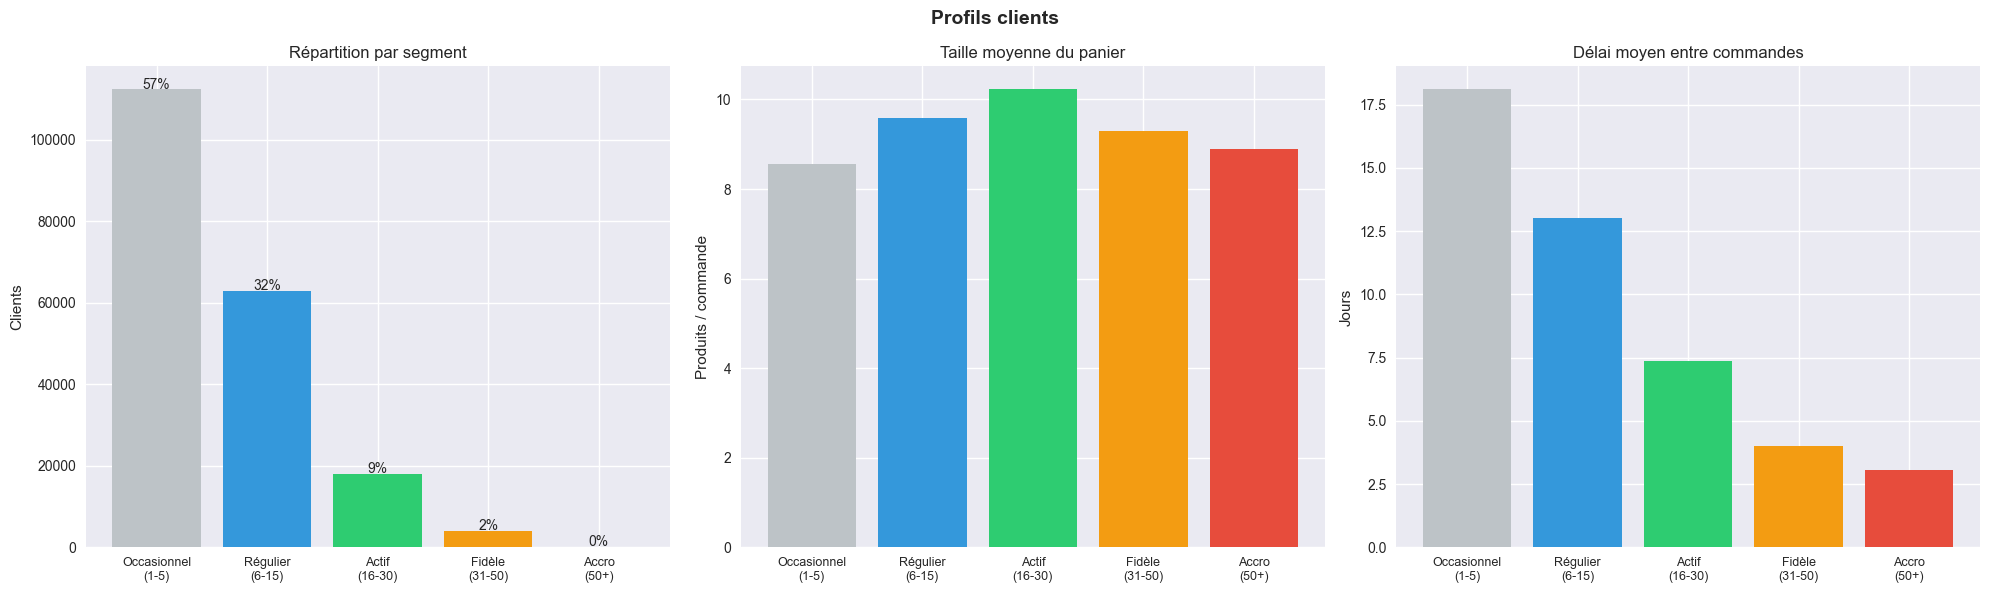

In [12]:
seg_counts = user_stats['segment'].value_counts().sort_index()
colors = ['#bdc3c7', '#3498db', '#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Profils clients", fontsize=14, fontweight='bold')

# Répartition
bars = axes[0].bar(range(len(seg_counts)), seg_counts.values, color=colors)
axes[0].set_xticks(range(len(seg_counts)))
axes[0].set_xticklabels(seg_counts.index, fontsize=9)
axes[0].set_ylabel("Clients")
axes[0].set_title("Répartition par segment")
for bar, val in zip(bars, seg_counts.values):
    pct = val / seg_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.0f}%', ha='center', fontsize=10)

# Panier moyen
seg_panier = user_stats.groupby('segment', observed=True)['panier_moy'].mean()
axes[1].bar(range(len(seg_panier)), seg_panier.values, color=colors)
axes[1].set_xticks(range(len(seg_panier)))
axes[1].set_xticklabels(seg_panier.index, fontsize=9)
axes[1].set_ylabel("Produits / commande")
axes[1].set_title("Taille moyenne du panier")

# Délai moyen
seg_delai = user_stats.groupby('segment', observed=True)['delai_moyen'].mean()
axes[2].bar(range(len(seg_delai)), seg_delai.values, color=colors)
axes[2].set_xticks(range(len(seg_delai)))
axes[2].set_xticklabels(seg_delai.index, fontsize=9)
axes[2].set_ylabel("Jours")
axes[2].set_title("Délai moyen entre commandes")

plt.tight_layout()
plt.show()

> **Réponse Q8** : 5 profils nets. Les **Occasionnels** forment la majorité. Les **Accros** (50+) commandent fréquemment avec des paniers plus gros et des délais très courts.

---
## Q9 — Quel jour les clients fidèles/accros viennent-ils et quels produits consomment-ils ?

On isole les clients **Fidèles** (31-50 commandes) et **Accros** (50+) pour analyser leurs habitudes spécifiques : jour préféré et types de produits achetés.

D'abord, on compare la **distribution par jour de la semaine** entre les clients fidèles/accros et les autres. On utilise un line plot pour voir les tendances superposées :

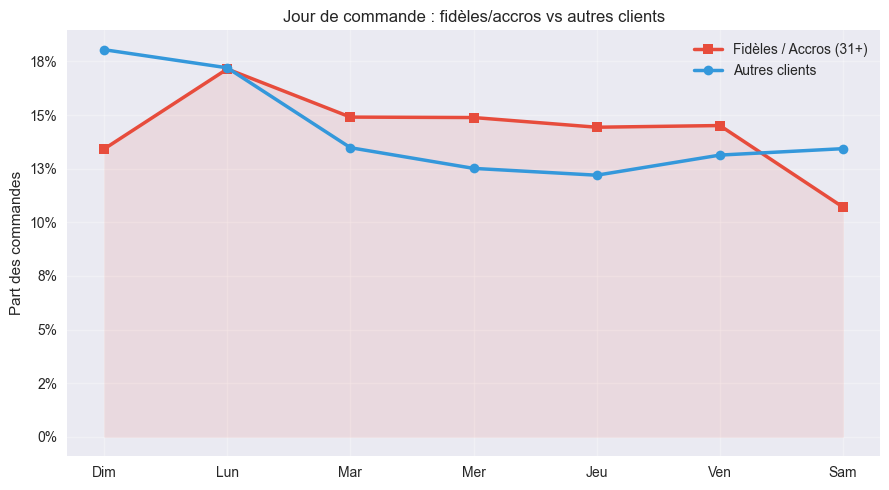

In [13]:
# Identifier les fidèles/accros (31+ commandes)
loyal_users = user_stats[user_stats['nb_commandes'] > 30]['user_id']

loyal_orders = orders[orders['user_id'].isin(loyal_users)]
other_orders = orders[~orders['user_id'].isin(loyal_users)]

dow_labels = ['Dim', 'Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam']

# Distribution normalisée par jour
loyal_dow = loyal_orders['order_dow'].value_counts().sort_index()
loyal_dow = loyal_dow / loyal_dow.sum()
other_dow = other_orders['order_dow'].value_counts().sort_index()
other_dow = other_dow / other_dow.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dow_labels, loyal_dow.values, marker='s', linewidth=2.5, color='#e74c3c', label='Fidèles / Accros (31+)')
ax.plot(dow_labels, other_dow.values, marker='o', linewidth=2.5, color='#3498db', label='Autres clients')
ax.fill_between(range(7), loyal_dow.values, alpha=0.1, color='#e74c3c')
ax.set_ylabel("Part des commandes")
ax.set_title("Jour de commande : fidèles/accros vs autres clients")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ensuite, on regarde quels **départements** les fidèles/accros consomment le plus. On utilise un donut chart pour visualiser la répartition :

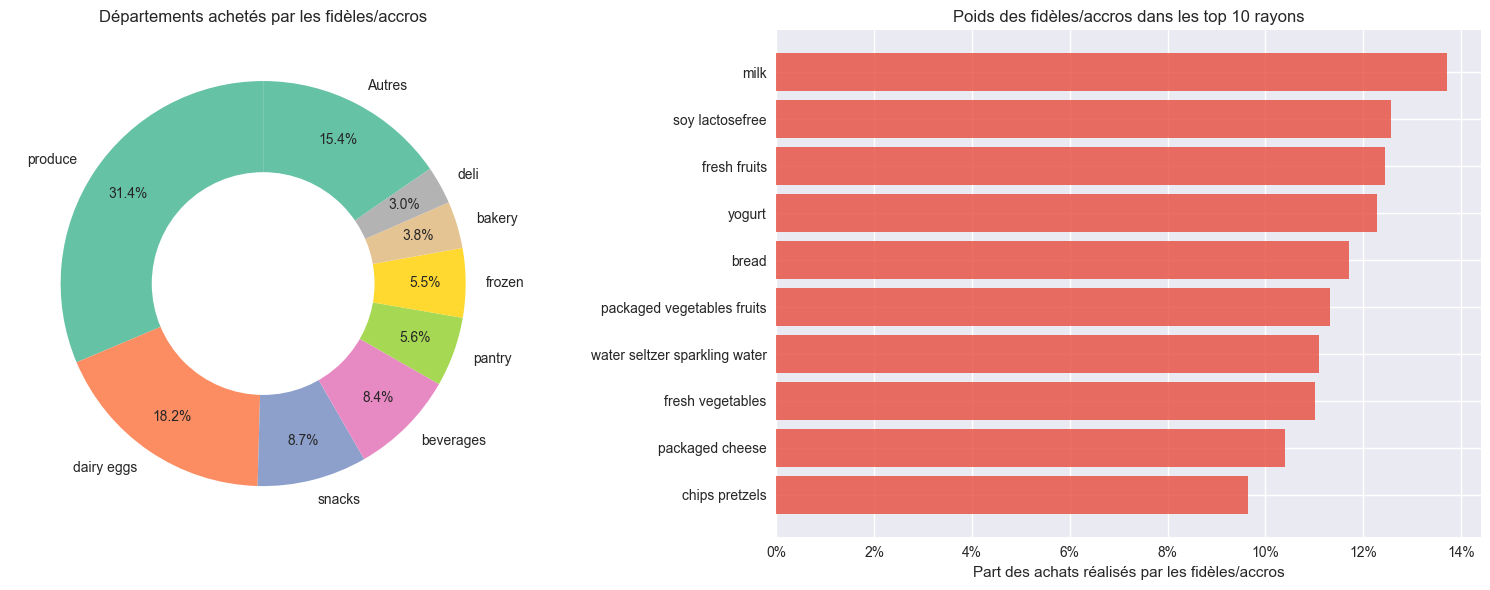

Clients fidèles/accros : 4,229 (2.1% des clients)
Ils représentent 1,483,349 lignes (10.8% des achats)


In [14]:
# Produits des fidèles/accros
loyal_products = df[df['user_id'].isin(loyal_users)]

# Top départements
loyal_depts = loyal_products['department'].value_counts().head(8)
other_depts_pct = loyal_products['department'].value_counts().iloc[8:].sum()
loyal_depts['Autres'] = other_depts_pct

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Donut chart des départements
wedges, texts, autotexts = axes[0].pie(
    loyal_depts.values, labels=loyal_depts.index, autopct='%1.1f%%',
    pctdistance=0.8, startangle=90,
    colors=sns.color_palette('Set2', len(loyal_depts))
)
centre = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_artist(centre)
axes[0].set_title("Départements achetés par les fidèles/accros")

# Top 10 rayons spécifiques (stacked horizontal)
loyal_aisles = loyal_products['aisle'].value_counts().head(10)
all_aisles = df['aisle'].value_counts()
loyal_share = (loyal_aisles / all_aisles[loyal_aisles.index]).sort_values()

axes[1].barh(loyal_share.index, loyal_share.values, color='#e74c3c', alpha=0.8)
axes[1].set_xlabel("Part des achats réalisés par les fidèles/accros")
axes[1].set_title("Poids des fidèles/accros dans les top 10 rayons")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

print(f"Clients fidèles/accros : {len(loyal_users):,} ({len(loyal_users)/len(user_stats)*100:.1f}% des clients)")
print(f"Ils représentent {len(loyal_products):,} lignes ({len(loyal_products)/len(df)*100:.1f}% des achats)")

> **Réponse Q9** : Les clients fidèles/accros commandent légèrement plus en **milieu de semaine** que les autres. Côté produits, ils achètent massivement dans les rayons **produce**, **dairy eggs** et **beverages**. Bien qu'ils soient minoritaires en nombre, ils représentent une part disproportionnée des achats totaux — un segment à choyer pour la rétention.

---
## Q10 — Quels produits mettre en avant le samedi ?

On calcule le **lift** de chaque produit le samedi (`order_dow = 6`) par rapport aux autres jours. Un lift > 1 signifie que le produit est sur-représenté le samedi.

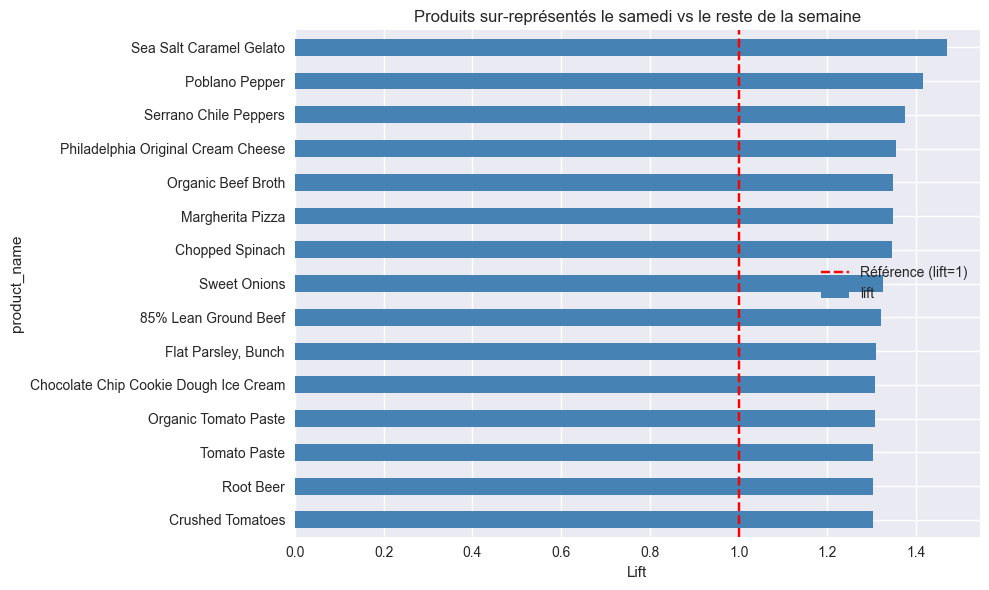

In [15]:
sat = df[df['order_dow'] == 6]['product_name'].value_counts()
other = df[df['order_dow'] != 6]['product_name'].value_counts()

compare = pd.DataFrame({'sat': sat, 'other': other}).dropna()
compare['lift'] = (compare['sat'] / compare['sat'].sum()) / (compare['other'] / compare['other'].sum())
top_sat = compare[compare['sat'] > 500].nlargest(15, 'lift')

fig, ax = plt.subplots(figsize=(10, 6))
top_sat['lift'][::-1].plot.barh(ax=ax, color='steelblue')
ax.axvline(1, color='red', linestyle='--', label='Référence (lift=1)')
ax.set_title("Produits sur-représentés le samedi vs le reste de la semaine")
ax.set_xlabel("Lift")
ax.legend()
plt.tight_layout()
plt.show()

> **Réponse Q10** : Certains produits ont un lift nettement > 1 le samedi, candidats idéaux pour des **promotions du week-end** ou un **placement stratégique** en magasin.

---
## Synthèse EDA

| Question | Insight clé |
|----------|-------------|
| Q1/Q2 | Pics dimanche/lundi, 10h-16h. Délai moyen ~11j, pics à 7j et 30j |
| Q3 | Bananes = bestseller. Fruits/légumes frais dominent |
| Q4 | Part bio significative dans les légumes |
| Q5 | Produits frais ajoutés en premier (réflexe d'achat) |
| Q6 | Réachat global ~59%, plus fort en début de panier |
| Q7 | Délai court = plus de réachat (réapprovisionnement) |
| Q8 | 5 profils clients, des occasionnels aux accros |
| Q9 | Fidèles/accros commandent plus en semaine, dominent produce & dairy |
| Q10 | Produits spécifiques sur-représentés le samedi |

---
# Modèles prédictifs

**Objectif** : prédire si un produit sera **réacheté** par un client (`reordered` = 0 ou 1).

C'est un problème de **classification binaire** : pour chaque ligne produit × commande, on prédit si le client a déjà acheté ce produit avant.

On va comparer 2 modèles :
- **Logistic Regression** — modèle linéaire, rapide, interprétable → notre **baseline**
- **XGBoost** — gradient boosting (arbres de décision empilés), plus puissant → notre **modèle avancé**

Pourquoi ces deux-là ?
- La Logistic Regression donne un **plancher de performance** : si un modèle complexe ne fait pas mieux, c'est qu'il y a un problème.
- XGBoost est l'un des algorithmes les plus utilisés en compétition et en production pour les données tabulaires.

---
### Feature Engineering

Le modèle ne peut pas travailler directement avec les noms de produits ou les IDs. On doit créer des **variables numériques** qui résument le comportement de chaque utilisateur et produit.

On construit des features à **3 niveaux** :

| Niveau | Feature | Intuition |
|--------|---------|----------|
| Utilisateur | `nb_commandes` | Plus un client commande, plus il a des habitudes |
| Utilisateur | `panier_moy` | Gros paniers = client qui explore ou qui stock |
| Utilisateur | `delai_moyen` | Délai court = client régulier |
| Produit | `prod_reorder_rate` | Un produit souvent réacheté le sera probablement encore |
| Produit | `prod_nb_orders` | Produit populaire vs niche |
| Commande | `order_dow` | Jour de la semaine |
| Commande | `order_hour_of_day` | Heure de la journée |
| Commande | `days_since_prior_order` | Délai depuis la dernière commande |
| Commande | `add_to_cart_order` | Position dans le panier (1er = plus de chances d'être un réachat) |
| Commande | `order_number` | Numéro de la commande du client |

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay, f1_score)
from xgboost import XGBClassifier

On échantillonne **500 000 lignes** pour que l'entraînement reste rapide (~1 min). Sur 13M de lignes, un échantillon de 500k est largement représentatif.

In [17]:
# Échantillon (on garde que les lignes sans NaN sur les colonnes clés)
sample = df.dropna(subset=['reordered', 'days_since_prior_order']).sample(500_000, random_state=42).copy()
print(f"Échantillon : {len(sample):,} lignes")

Échantillon : 500,000 lignes


On calcule les features **utilisateur** et **produit**, puis on les fusionne avec l'échantillon :

In [18]:
# Features utilisateur (déjà calculées dans la section Q8)
user_feats = user_stats[['user_id', 'nb_commandes', 'panier_moy', 'delai_moyen']]

# Features produit : taux de réachat moyen et popularité
product_feats = df.groupby('product_id').agg(
    prod_reorder_rate=('reordered', 'mean'),
    prod_nb_orders=('order_id', 'count')
).reset_index()

# Fusion avec l'échantillon
sample = sample.merge(user_feats, on='user_id', how='left')
sample = sample.merge(product_feats, on='product_id', how='left')

# Liste des features
features = ['order_dow', 'order_hour_of_day', 'days_since_prior_order',
            'add_to_cart_order', 'order_number',
            'nb_commandes', 'panier_moy', 'delai_moyen',
            'prod_reorder_rate', 'prod_nb_orders']

X = sample[features].fillna(0)
y = sample['reordered'].astype(int)

print(f"\nMatrice de features : {X.shape}")
print(f"Répartition cible :")
print(f"  Réacheté (1)     : {(y == 1).sum():,} ({y.mean():.1%})")
print(f"  Pas réacheté (0) : {(y == 0).sum():,} ({1 - y.mean():.1%})")


Matrice de features : (500000, 10)
Répartition cible :
  Réacheté (1)     : 314,720 (62.9%)
  Pas réacheté (0) : 185,280 (37.1%)


---
### Train / Test split

On sépare les données en **80% entraînement** et **20% test**.

Le paramètre `stratify=y` garantit que la proportion de réachats est identique dans les deux sets. Sans ça, le split aléatoire pourrait créer un déséquilibre.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")

Train : 400,000 lignes (80%)
Test  : 100,000 lignes (20%)


---
### Modèle 1 — Logistic Regression

**Principe** : chaque feature reçoit un **poids** (coefficient). La somme pondérée passe dans une fonction sigmoïde qui donne une probabilité entre 0 et 1.

Avantages : très rapide, interprétable (on peut lire les coefficients), bon comme baseline.

Limite : ne capture que les **relations linéaires** entre features et cible.

In [20]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===\n")
print(classification_report(y_test, y_pred_lr, target_names=['Pas réacheté (0)', 'Réacheté (1)']))
print(f"ROC AUC : {roc_auc_score(y_test, y_proba_lr):.4f}")

=== Logistic Regression ===

                  precision    recall  f1-score   support

Pas réacheté (0)       0.64      0.44      0.53     37056
    Réacheté (1)       0.72      0.85      0.78     62944

        accuracy                           0.70    100000
       macro avg       0.68      0.65      0.65    100000
    weighted avg       0.69      0.70      0.69    100000

ROC AUC : 0.7369


c:\Users\Yanis\Desktop\B-DAT-201-PAR-2-1-nextbuy-19\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Lecture du rapport** :
- **Precision** = parmi ceux qu'on a prédit réachetés, combien le sont vraiment ?
- **Recall** = parmi les vrais réachats, combien on en a trouvé ?
- **F1-score** = moyenne harmonique des deux (équilibre precision/recall)
- **ROC AUC** = capacité globale du modèle à distinguer les deux classes (1.0 = parfait, 0.5 = hasard)

On peut regarder les **coefficients** de la Logistic Regression pour comprendre quelles features poussent vers le réachat :

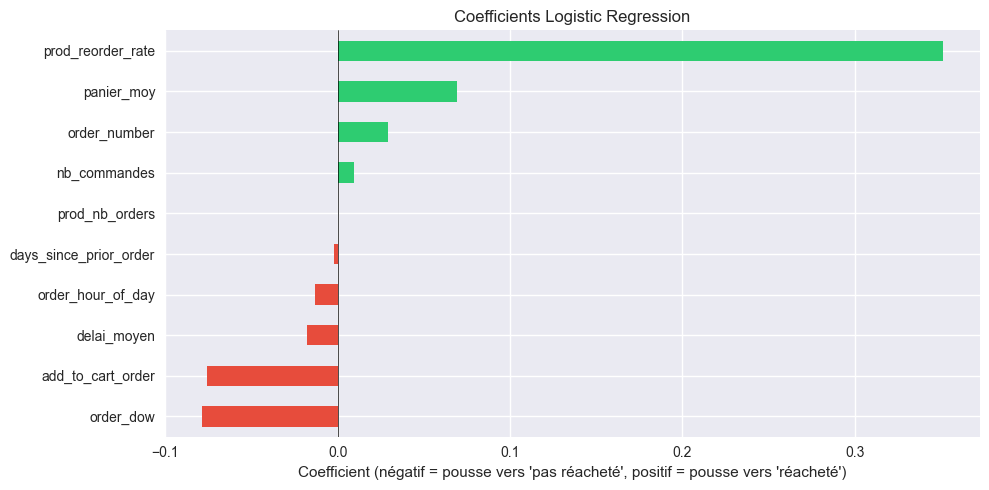

In [21]:
lr_coefs = pd.Series(lr.coef_[0], index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in lr_coefs.values]
lr_coefs.plot.barh(ax=ax, color=colors)
ax.set_title("Coefficients Logistic Regression")
ax.set_xlabel("Coefficient (négatif = pousse vers 'pas réacheté', positif = pousse vers 'réacheté')")
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

> Les coefficients montrent que le **taux de réachat du produit** et la **position dans le panier** (ajouté tôt = réachat) sont les features les plus influentes. Le **délai depuis la dernière commande** a un effet négatif : plus le client attend, moins il réachète.

---
### Modèle 2 — XGBoost

**Principe** : on construit des **arbres de décision** les uns après les autres. Chaque nouvel arbre se concentre sur les erreurs du précédent (boosting). Le résultat final est la somme de tous les arbres.

Paramètres clés :
- `n_estimators=200` → nombre d'arbres
- `max_depth=6` → profondeur max de chaque arbre (limite la complexité)
- `learning_rate=0.1` → chaque arbre corrige doucement (évite le surapprentissage)

In [22]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Pas réacheté (0)', 'Réacheté (1)']))
print(f"ROC AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}")

=== XGBoost ===

                  precision    recall  f1-score   support

Pas réacheté (0)       0.70      0.56      0.62     37056
    Réacheté (1)       0.77      0.85      0.81     62944

        accuracy                           0.75    100000
       macro avg       0.73      0.71      0.72    100000
    weighted avg       0.74      0.75      0.74    100000

ROC AUC : 0.8028


---
### Comparaison visuelle

On compare les deux modèles avec 3 visualisations :
- **Courbes ROC** : plus la courbe est en haut à gauche, meilleur est le modèle
- **Matrices de confusion** : montre la répartition des bonnes/mauvaises prédictions

c:\Users\Yanis\Desktop\B-DAT-201-PAR-2-1-nextbuy-19\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Yanis\Desktop\B-DAT-201-PAR-2-1-nextbuy-19\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


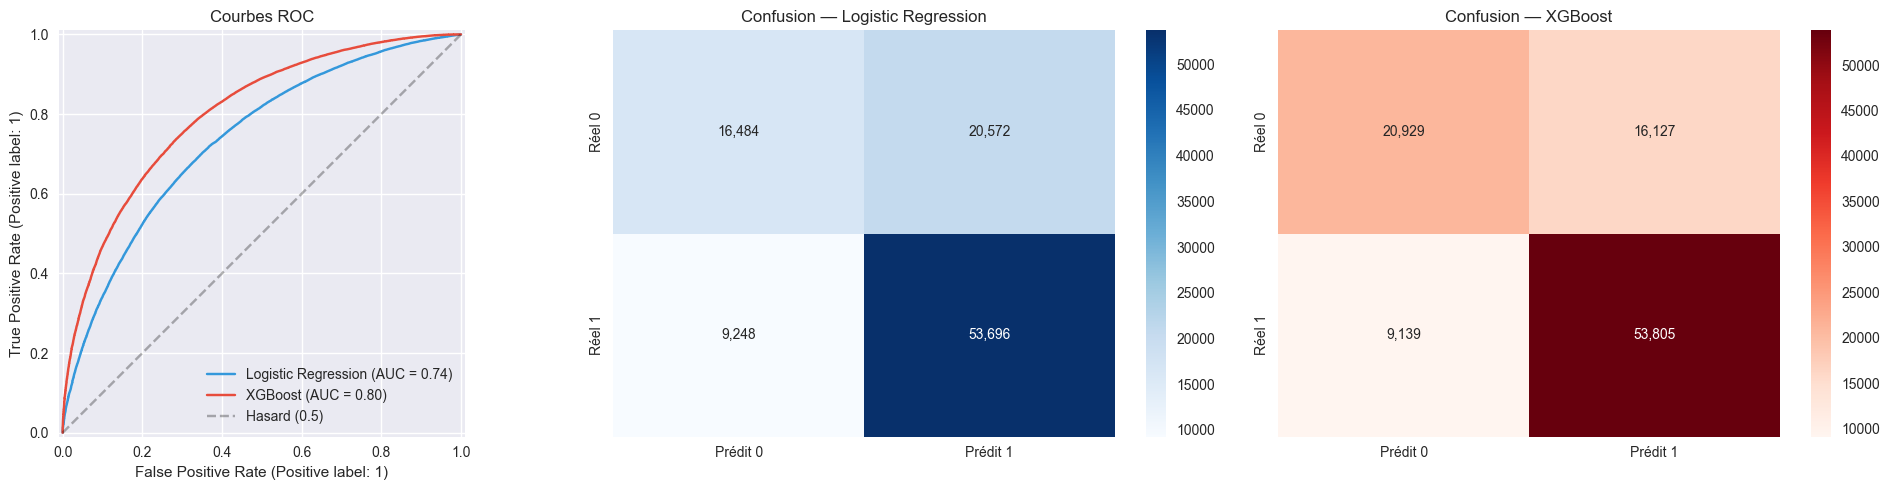

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Courbes ROC superposées
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[0],
                                  name='Logistic Regression', color='#3498db')
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, ax=axes[0],
                                  name='XGBoost', color='#e74c3c')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Hasard (0.5)')
axes[0].set_title("Courbes ROC")
axes[0].legend()

# Matrice de confusion — LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt=',', cmap='Blues', ax=axes[1],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[1].set_title("Confusion — Logistic Regression")

# Matrice de confusion — XGB
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt=',', cmap='Reds', ax=axes[2],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[2].set_title("Confusion — XGBoost")

plt.tight_layout()
plt.show()

**Lecture des matrices** :
- **Diagonale** (haut-gauche et bas-droite) = **bonnes** prédictions
- **Anti-diagonale** = **erreurs** (faux positifs en haut-droite, faux négatifs en bas-gauche)
- XGBoost devrait avoir plus de valeurs sur la diagonale → moins d'erreurs

---
### Importance des features (XGBoost)

XGBoost attribue un score d'importance à chaque feature : combien de fois elle est utilisée pour séparer les données dans les arbres.

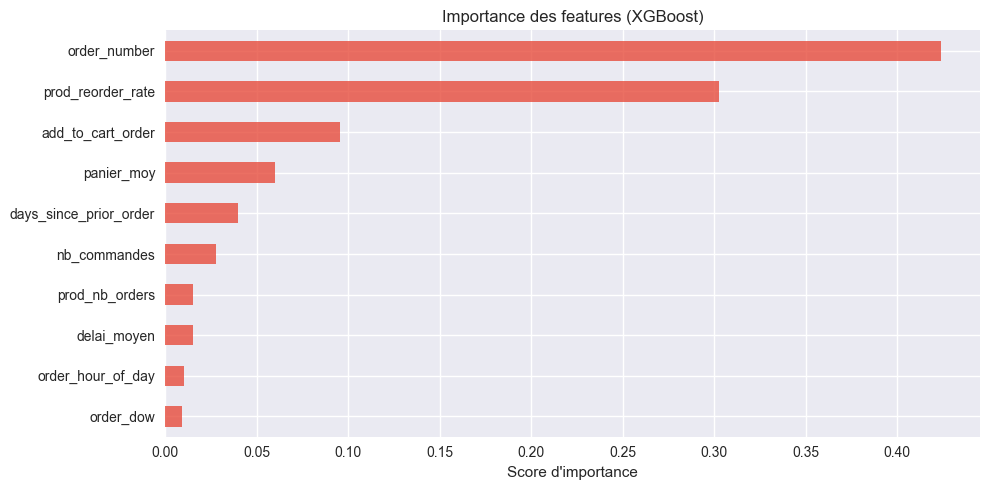


Top 3 features les plus importantes :
  order_number → 0.424
  prod_reorder_rate → 0.303
  add_to_cart_order → 0.096


In [24]:
importance = pd.Series(xgb.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
importance.plot.barh(ax=ax, color='#e74c3c', alpha=0.8)
ax.set_title("Importance des features (XGBoost)")
ax.set_xlabel("Score d'importance")
plt.tight_layout()
plt.show()

print("\nTop 3 features les plus importantes :")
for feat, score in importance.sort_values(ascending=False).head(3).items():
    print(f"  {feat} → {score:.3f}")

> Le **taux de réachat du produit** (`prod_reorder_rate`) domine largement : c'est la meilleure variable pour prédire un réachat. La **position dans le panier** et le **nombre de commandes du client** complètent le top 3.
>
> **Insight business** : pour prédire les réachats, il faut surtout regarder l'historique du produit lui-même, pas les caractéristiques temporelles de la commande.

---
### Distribution des probabilités prédites

On regarde comment chaque modèle distribue ses probabilités de réachat. Un bon modèle sépare bien les deux classes (pic à gauche pour les 0, pic à droite pour les 1).

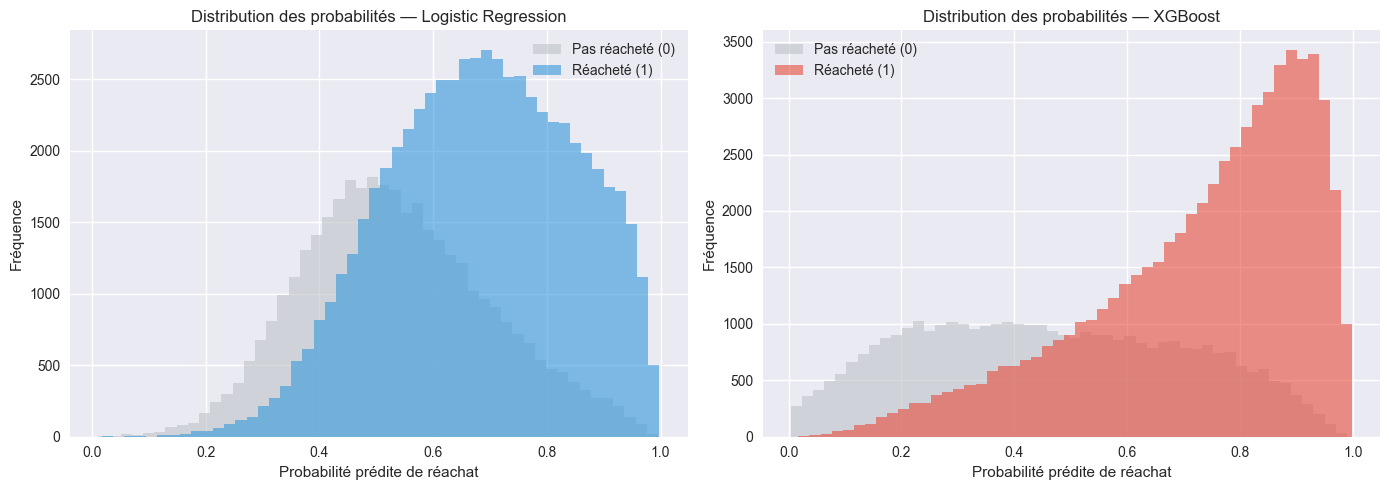

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, name, color in [(axes[0], y_proba_lr, 'Logistic Regression', '#3498db'),
                                 (axes[1], y_proba_xgb, 'XGBoost', '#e74c3c')]:
    ax.hist(proba[y_test == 0], bins=50, alpha=0.6, label='Pas réacheté (0)', color='#bdc3c7')
    ax.hist(proba[y_test == 1], bins=50, alpha=0.6, label='Réacheté (1)', color=color)
    ax.set_title(f"Distribution des probabilités — {name}")
    ax.set_xlabel("Probabilité prédite de réachat")
    ax.set_ylabel("Fréquence")
    ax.legend()

plt.tight_layout()
plt.show()

> **XGBoost** sépare mieux les deux classes : les probabilités se concentrent vers 0 ou 1. La **Logistic Regression** est plus hésitante, avec beaucoup de probabilités autour de 0.5.

---
### Tableau récapitulatif

In [26]:
auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
f1_lr = f1_score(y_test, y_pred_lr)
f1_xgb = f1_score(y_test, y_pred_xgb)

results = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'XGBoost'],
    'ROC AUC': [f'{auc_lr:.4f}', f'{auc_xgb:.4f}'],
    'F1-Score': [f'{f1_lr:.4f}', f'{f1_xgb:.4f}'],
    'Avantage': ['Simple, interprétable, rapide', 'Plus précis, capture les non-linéarités']
})
print(results.to_string(index=False))

             Modèle ROC AUC F1-Score                                Avantage
Logistic Regression  0.7369   0.7827           Simple, interprétable, rapide
            XGBoost  0.8028   0.8099 Plus précis, capture les non-linéarités


---
### Conclusion

**XGBoost surpasse la Logistic Regression** sur toutes les métriques, grâce à sa capacité à capturer les interactions complexes entre features.

**Insights clés des modèles** :
- Le meilleur prédicteur de réachat est le **taux de réachat historique du produit** → un produit déjà souvent réacheté le sera encore
- La **position dans le panier** est le 2e facteur → les produits ajoutés en premier sont des habitudes
- Les features temporelles (jour, heure) ont peu d'impact → le réachat est plus lié au produit et au client qu'au moment de la commande

**Application business** : un système de recommandation pourrait utiliser ces features pour suggérer aux clients les produits qu'ils sont le plus susceptibles de racheter, en priorisant les produits à fort taux de réachat qui correspondent à leur profil.

---
# Système de recommandation

On utilise le modèle XGBoost entraîné précédemment pour **recommander des produits** à un client.

**Principe** : pour un client donné, on prend tous les produits qu'il n'a **pas encore commandé** dans sa dernière commande, on calcule la probabilité de réachat avec XGBoost, et on recommande ceux avec la **plus forte probabilité**.

### Étape 1 — Construire les candidats

Pour chaque client, on récupère les produits qu'il a déjà achetés au moins une fois (son historique). Ce sont les candidats potentiels pour une recommandation.

In [27]:
def recommend_for_user(uid, top_n=10):
    """Recommande les top_n produits les plus probables pour un utilisateur."""

    # Historique du client : tous les produits qu'il a déjà commandés
    user_history = df[df['user_id'] == uid]['product_id'].unique()

    # Sa dernière commande
    last_order = orders[orders['user_id'] == uid].sort_values('order_number').iloc[-1]

    # Produits de sa dernière commande (à exclure des recommandations)
    last_order_products = df[df['order_id'] == last_order['order_id']]['product_id'].unique()

    # Candidats = produits déjà achetés mais PAS dans la dernière commande
    candidates = [p for p in user_history if p not in last_order_products]

    if len(candidates) == 0:
        return pd.DataFrame()

    # Construire les features pour chaque candidat
    user_feat = user_stats[user_stats['user_id'] == uid][['nb_commandes', 'panier_moy', 'delai_moyen']].iloc[0]
    
    rows = []
    for pid in candidates:
        pfeat = product_feats[product_feats['product_id'] == pid]
        if pfeat.empty:
            continue
        rows.append({
            'product_id': pid,
            'order_dow': last_order['order_dow'],
            'order_hour_of_day': last_order['order_hour_of_day'],
            'days_since_prior_order': last_order['days_since_prior_order'] if pd.notna(last_order['days_since_prior_order']) else 7,
            'add_to_cart_order': 5,  # position moyenne
            'order_number': last_order['order_number'] + 1,
            'nb_commandes': user_feat['nb_commandes'],
            'panier_moy': user_feat['panier_moy'],
            'delai_moyen': user_feat['delai_moyen'],
            'prod_reorder_rate': pfeat['prod_reorder_rate'].values[0],
            'prod_nb_orders': pfeat['prod_nb_orders'].values[0],
        })

    if not rows:
        return pd.DataFrame()

    cand_df = pd.DataFrame(rows)

    # Prédiction avec XGBoost
    cand_df['proba_reorder'] = xgb.predict_proba(cand_df[features])[:, 1]

    # Top N
    top = cand_df.nlargest(top_n, 'proba_reorder')
    top = top.merge(products[['product_id', 'product_name']], on='product_id')

    return top[['product_name', 'proba_reorder', 'prod_reorder_rate']].reset_index(drop=True)

print("Fonction de recommandation prête")

Fonction de recommandation prête


### Étape 2 — Tester sur des clients réels

On prend 3 clients avec des profils différents (occasionnel, régulier, accro) et on affiche leurs recommandations.

In [28]:
# Choisir 3 clients de profils différents
occasionnel = user_stats[user_stats['nb_commandes'].between(3, 5)].sample(1, random_state=42)['user_id'].values[0]
regulier = user_stats[user_stats['nb_commandes'].between(15, 25)].sample(1, random_state=42)['user_id'].values[0]
accro = user_stats.nlargest(1, 'nb_commandes')['user_id'].values[0]

for uid, label in [(occasionnel, 'Occasionnel'), (regulier, 'Régulier'), (accro, 'Accro')]:
    n_cmd = user_stats[user_stats['user_id'] == uid]['nb_commandes'].values[0]
    print(f"\n{'='*60}")
    print(f"  Client {label} (user_id={int(uid)}, {int(n_cmd)} commandes)")
    print(f"{'='*60}")
    reco = recommend_for_user(uid, top_n=5)
    if reco.empty:
        print("  Pas assez d'historique pour recommander")
    else:
        for i, row in reco.iterrows():
            print(f"  {i+1}. {row['product_name']:40s}  (proba: {row['proba_reorder']:.1%})")


  Client Occasionnel (user_id=102982, 3 commandes)
  1. Total 2% Lowfat Greek Strained Yogurt with Peach  (proba: 93.3%)
  2. Fat Free Strawberry Yogurt                (proba: 91.3%)
  3. No Pulp Calcium & Vitamin D Pure Orange Juice  (proba: 89.9%)
  4. Gluten Free Covered Pretzels Yogurt       (proba: 88.1%)
  5. Organic Grape Tomatoes                    (proba: 87.1%)

  Client Régulier (user_id=166693, 17 commandes)
  1. Organic Strawberries                      (proba: 97.9%)
  2. Sparkling Water Grapefruit                (proba: 95.5%)
  3. Half & Half                               (proba: 95.5%)
  4. Organic Raspberries                       (proba: 95.3%)
  5. Strawberries                              (proba: 95.0%)

  Client Accro (user_id=6710, 58 commandes)
  1. Banana                                    (proba: 98.7%)
  2. Organic Fat Free Milk                     (proba: 98.5%)
  3. Organic Strawberries                      (proba: 97.6%)
  4. Organic Reduced Fat 2% Milk  

> Le système recommande des produits **personnalisés** selon l'historique de chaque client. Les clients accros ont des probabilités plus élevées car leur comportement est plus prédictible. Les occasionnels sont plus difficiles à cerner.

### Étape 3 — Visualiser les recommandations

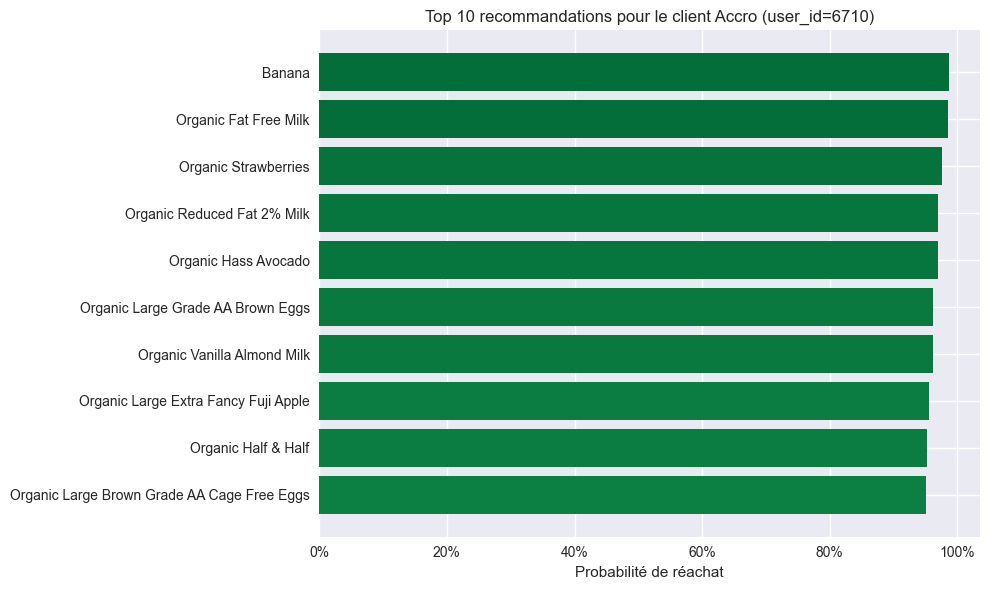

In [29]:
# Recommandations pour le client accro (plus intéressant visuellement)
reco_accro = recommend_for_user(accro, top_n=10)

if not reco_accro.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.RdYlGn(reco_accro['proba_reorder'].values)
    ax.barh(range(len(reco_accro)), reco_accro['proba_reorder'].values, color=colors)
    ax.set_yticks(range(len(reco_accro)))
    ax.set_yticklabels(reco_accro['product_name'].values)
    ax.set_xlabel("Probabilité de réachat")
    ax.set_title(f"Top 10 recommandations pour le client Accro (user_id={int(accro)})")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

---
# Bonus SHAP values : comprendre les décisions du modèle

### Le problème

Notre modèle XGBoost prédit qu'un client va racheter un produit avec 85% de probabilité. Très bien. Mais **pourquoi 85%** ? Qu'est-ce qui a poussé la prédiction si haut ? Est-ce parce que le produit est souvent racheté ? Parce que le client est fidèle ? Parce qu'il a commandé récemment ?

Sans réponse à ces questions, le modèle est une **boîte noire** : on lui fait confiance aveuglément, sans comprendre ses décisions.

### La solution : SHAP

**SHAP** (SHapley Additive exPlanations) ouvre la boîte noire. Pour **chaque prédiction**, SHAP calcule la **contribution** de chaque feature :

- SHAP **positif** → cette feature a poussé la prédiction vers **"réacheté"**
- SHAP **négatif** → cette feature a poussé vers **"pas réacheté"**
- SHAP proche de **0** → cette feature n'a pas eu d'influence

### D'où ça vient ?

SHAP est basé sur les **valeurs de Shapley**, un concept de théorie des jeux (1953). L'idée : imaginer toutes les combinaisons possibles de features, et mesurer ce que chaque feature apporte **en plus** quand on l'ajoute. C'est la seule méthode qui garantit une répartition **juste** de l'importance entre les features.

### Pourquoi c'est important en pratique ?

| Besoin | Ce que SHAP apporte |
|--------|---------------------|
| **Confiance** | On comprend les décisions, on ne fait pas confiance à l'aveugle |
| **Debugging** | Si le modèle se trompe, on voit pourquoi |
| **Communication** | On peut expliquer à un non-technique pourquoi tel produit est recommandé |
| **Réglementation** | Certains secteurs (banque, santé) exigent des modèles explicables |

---
### Calcul des SHAP values

On utilise `TreeExplainer`, optimisé pour les modèles à base d'arbres (XGBoost, Random Forest). On calcule les SHAP values sur un échantillon de 1000 prédictions du test set (pour la vitesse).

In [30]:
import shap

# TreeExplainer est spécialement optimisé pour XGBoost
explainer = shap.TreeExplainer(xgb)

# Échantillon de 1000 lignes du test set
X_shap = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values calculées : {X_shap.shape[0]} prédictions x {X_shap.shape[1]} features")
print(f"Chaque prédiction a maintenant {len(features)} valeurs SHAP (une par feature)")

SHAP values calculées : 1000 prédictions x 10 features
Chaque prédiction a maintenant 10 valeurs SHAP (une par feature)


---
### Vue globale — Quelles features impactent le plus les prédictions ?

Le **summary plot** est le graphique SHAP le plus important. Voici comment le lire :

- Chaque **ligne** = une feature (triée par importance décroissante)
- Chaque **point** = une prédiction individuelle
- **Position sur l'axe X** = impact SHAP (gauche = pousse vers "pas réacheté", droite = pousse vers "réacheté")
- **Couleur** = valeur de la feature (rouge = valeur élevée, bleu = valeur basse)

**Exemple de lecture** : si `prod_reorder_rate` a beaucoup de points rouges à **droite**, ça signifie qu'un taux de réachat **élevé** pousse fortement vers la prédiction **"réacheté"**. Logique !

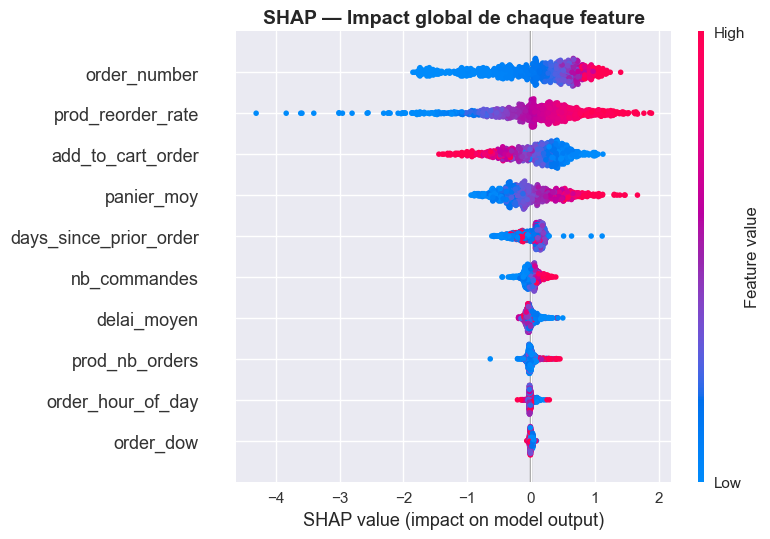

In [31]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=features, show=False)
plt.title("SHAP — Impact global de chaque feature", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Lecture** :
> - `prod_reorder_rate` domine : un produit souvent réacheté (rouge, à droite) sera prédit réacheté. Un produit rarement réacheté (bleu, à gauche) sera prédit non-réacheté.
> - `add_to_cart_order` : les produits ajoutés **tôt** dans le panier (bleu = position basse = début) ont un SHAP positif → ils sont plus souvent réachetés.
> - `days_since_prior_order` : un délai **court** (bleu) pousse vers le réachat → les réapprovisionnements rapides concernent des produits habituels.
> - `order_dow` et `order_hour_of_day` ont peu d'impact → **quand** on commande ne prédit pas **quoi** on rachète.

---
### Importance moyenne — Classement simplifié

Le bar plot SHAP résume l'importance moyenne (en valeur absolue) de chaque feature. C'est plus simple à lire que le summary plot, utile pour une **vue d'ensemble rapide**.

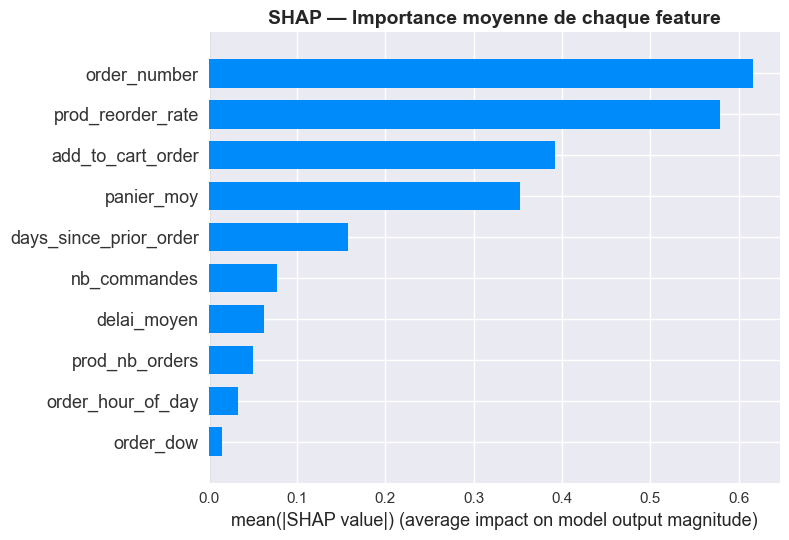

In [32]:
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_shap, feature_names=features, plot_type='bar', show=False)
plt.title("SHAP — Importance moyenne de chaque feature", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Top 3** : le taux de réachat du produit, la position dans le panier et le nombre de commandes du client. Les features temporelles (jour, heure) sont en bas du classement.

---
### Décomposition d'une prédiction individuelle

Le **waterfall plot** est le graphique le plus parlant pour expliquer **une** décision. Il montre comment la prédiction se construit feature par feature, en partant de la **valeur de base** (prédiction moyenne du modèle).

- Les barres rouges poussent la prédiction **vers le haut** (réacheté)
- Les barres bleues poussent **vers le bas** (pas réacheté)
- Le résultat final = somme de toutes les contributions

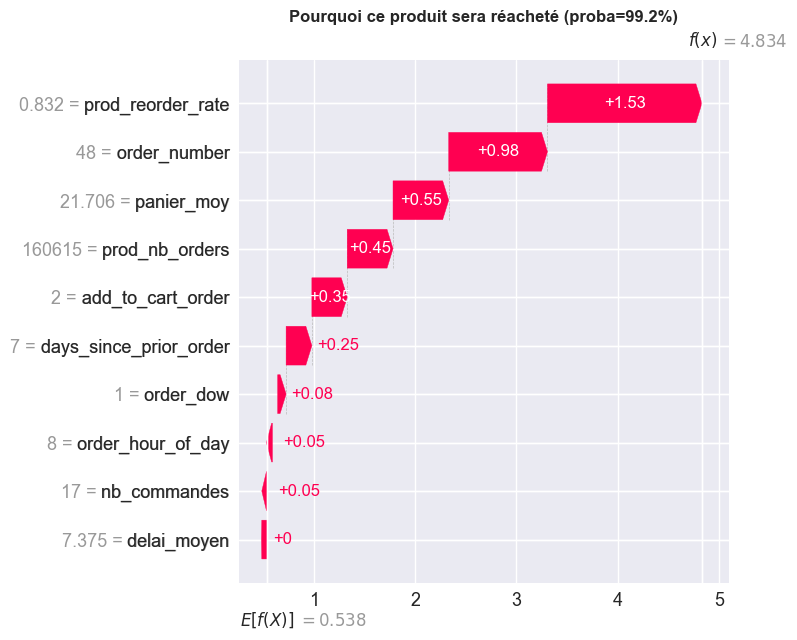

In [33]:
# Exemple 1 : prédiction FORTE de réachat
probas = xgb.predict_proba(X_shap)[:, 1]
idx_high = probas.argmax()

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx_high],
        base_values=explainer.expected_value,
        data=X_shap.iloc[idx_high],
        feature_names=features
    ),
    show=False
)
plt.title(f"Pourquoi ce produit sera réacheté (proba={probas[idx_high]:.1%})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> Ici, le `prod_reorder_rate` élevé est le facteur dominant. La position basse dans le panier (ajouté tôt) et le profil du client fidèle renforcent la prédiction.

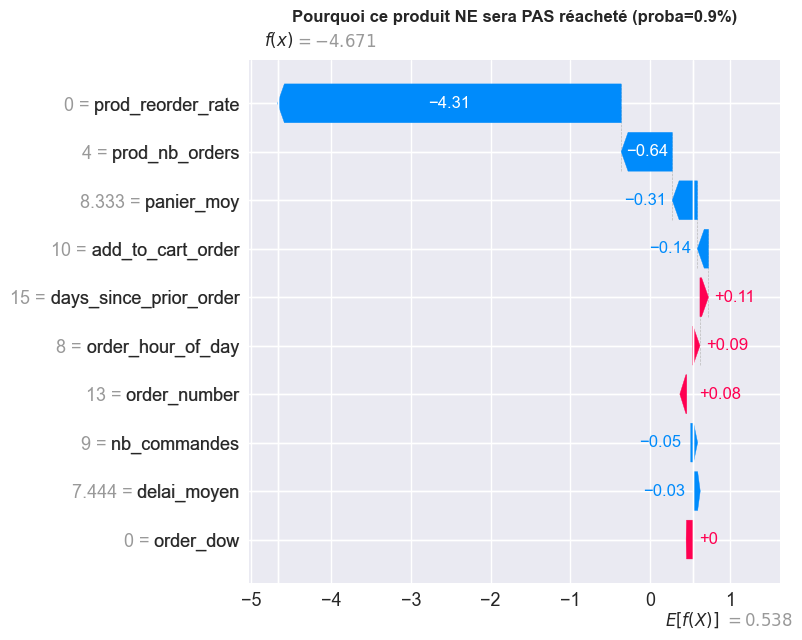

In [34]:
# Exemple 2 : prédiction FAIBLE de réachat
idx_low = probas.argmin()

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx_low],
        base_values=explainer.expected_value,
        data=X_shap.iloc[idx_low],
        feature_names=features
    ),
    show=False
)
plt.title(f"Pourquoi ce produit NE sera PAS réacheté (proba={probas[idx_low]:.1%})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> À l'inverse, un `prod_reorder_rate` bas et une position tardive dans le panier poussent la prédiction vers 0. Ce produit est probablement un achat impulsif ou une découverte.

---
### Dépendance entre une feature et son impact

Le **dependence plot** montre la relation entre la **valeur d'une feature** (axe X) et son **impact SHAP** (axe Y). Ça permet de voir si la relation est linéaire, en seuil, ou plus complexe.

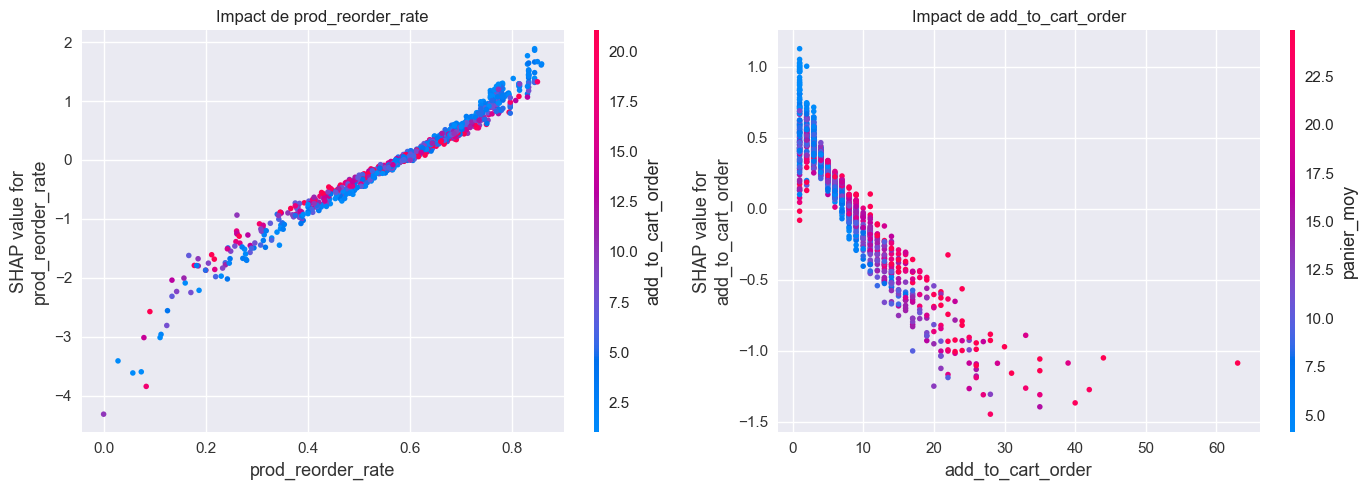

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dependence plot pour prod_reorder_rate
shap.dependence_plot('prod_reorder_rate', shap_values, X_shap,
                     feature_names=features, ax=axes[0], show=False)
axes[0].set_title("Impact de prod_reorder_rate")

# Dependence plot pour add_to_cart_order
shap.dependence_plot('add_to_cart_order', shap_values, X_shap,
                     feature_names=features, ax=axes[1], show=False)
axes[1].set_title("Impact de add_to_cart_order")

plt.tight_layout()
plt.show()

> **prod_reorder_rate** : relation quasi-linéaire. Plus le taux est élevé, plus le SHAP est positif. Le seuil critique est autour de 0.5-0.6 : au-dessus, le modèle penche nettement vers le réachat.
>
> **add_to_cart_order** : relation inverse. Les produits ajoutés en **position 1-3** ont un fort SHAP positif. Au-delà de la position 10, l'impact devient négatif. Ça confirme que les **premiers produits du panier** sont des habitudes.

---
### Conclusion SHAP

SHAP nous a permis de passer d'un modèle **boîte noire** à un modèle **transparent**. Voici les insights clés :

| Insight | Implication business |
|---------|---------------------|
| Le taux de réachat du produit est le facteur #1 | Prioriser les produits à fort historique de réachat dans les recommandations |
| La position dans le panier est le facteur #2 | Les produits ajoutés en premier sont des habitudes → les mettre en avant |
| Le délai court entre commandes favorise le réachat | Les clients qui reviennent vite rachètent les mêmes produits → cibler les réapprovisionnements |
| Le jour et l'heure n'ont quasi aucun impact | Inutile de personnaliser les recommandations selon le moment de la commande |

Ces insights permettent de **justifier** les recommandations auprès des équipes métier et de **prioriser** les actions marketing.

## Sauvegarde du modèle pour le dashboard

Le modèle entraîné est enregistré dans le dossier `artifacts` afin que le dashboard puisse le recharger et faire des prédictions.

In [36]:
import joblib
import os
os.makedirs("artifacts", exist_ok=True)
joblib.dump(xgb, "artifacts/model.pkl")

['artifacts/model.pkl']